# Calibração pós-treinamento e limiar de decisão

Quanto a calibração corrige as probabilidades dos 30 modelos de `output/modelos_v2/`, e qual limiar de decisão elas sustentam.
Aplica Platt scaling e regressão isotônica, e define o limiar sobre as probabilidades calibradas.
O ajuste dos calibradores e a escolha do limiar usam apenas o treino de 2020 a 2023; o teste de 2024 não entra em nenhum dos dois, e serve apenas para medir o que transfere.
Lê os modelos já ajustados de `output/modelos_v2/` e as bases das três configurações em `data/processed/`; nenhum modelo é retreinado.

## Etapas
1. Carregar as três bases e montar as partições de treino de 2020 a 2023 e teste de 2024.
2. Carregar os 30 modelos já ajustados, sem retreinar nenhum.
3. Definir as métricas com pesos, que permitem usar as mesmas reamostragens do bootstrap em todos os modelos.
4. Ajustar os calibradores por validação cruzada interna de 5 partições sobre o treino.
5. Conferir o atalho de ajuste contra `CalibratedClassifierCV` do scikit-learn.
6. Reunir as predições calibradas do teste e as predições fora da partição do treino.
7. Rodar o bootstrap de 2.000 reamostragens do teste de 2024.
8. Medir a calibração antes e depois: Brier Score, Brier Skill Score, AUPRC e ROC-AUC.
9. Comparar o limiar de 0,5 com o que atinge sensibilidade 0,80 na validação cruzada do treino.
10. Selecionar entre as versões base e otimizada de cada algoritmo pela AUPRC da validação cruzada.
11. Gravar as curvas de calibração por decil das dez combinações de algoritmo e versão, que são material suplementar, e as curvas de sensibilidade contra VPP.
12. Desenhar a figura principal: as curvas de calibração das cinco versões selecionadas da configuração final, com a tabela que as sustenta.
13. Contar os valores distintos de probabilidade predita no teste em cada estado de calibração.

## Entradas
- `output/modelos_v2/` (30 modelos ajustados)
- `data/processed/dengue_treated_antiga.parquet`
- `data/processed/dengue_treated_corrigida.parquet`
- `data/processed/dengue_treated_notificacao.parquet`

## Saídas
- `output/modelos_v2_calibrados/` (um arquivo por modelo, com o pipeline de origem e os dois calibradores)
- `output/metricas_v2_calibradas/` (predições calibradas, predições fora da partição e distribuições do bootstrap)
- `analysis/results_calibracao/particoes_temporais.csv`
- `analysis/results_calibracao/verificacao_calibradores.csv`
- `analysis/results_calibracao/calibracao_teste_2024.csv`
- `analysis/results_calibracao/limiares_teste_2024.csv`
- `analysis/results_calibracao/selecao_base_vs_otimizada.csv`
- `analysis/results_calibracao/calibracao_decis_final_selecionados.csv`
- `analysis/results_calibracao/patamares_predicoes_final.csv`
- `analysis/plots/calibracao/calibracao_decis_final_selecionados.png`
- `analysis/plots/calibracao/calibracao_decis_antiga.png`
- `analysis/plots/calibracao/calibracao_decis_corrigida.png`
- `analysis/plots/calibracao/calibracao_decis_notificacao.png`
- `analysis/plots/calibracao/sensibilidade_vpp_antiga.png`
- `analysis/plots/calibracao/sensibilidade_vpp_corrigida.png`
- `analysis/plots/calibracao/sensibilidade_vpp_notificacao.png`

Importações, caminhos, constantes e formatadores em português.

In [1]:
import os
import sys
import time
import textwrap
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import _SigmoidCalibration
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import configuracoes

PROC_DIR      = os.path.join(ROOT, 'data', 'processed')
DIR_MODELOS   = os.path.join(ROOT, 'output', 'modelos_v2')
DIR_CALIBRADOS = os.path.join(ROOT, 'output', 'modelos_v2_calibrados')
DIR_METRICAS  = os.path.join(ROOT, 'output', 'metricas_v2_calibradas')
DIR_TABELAS   = os.path.join(ROOT, 'analysis', 'results_calibracao')
DIR_FIGURAS   = os.path.join(ROOT, 'analysis', 'plots', 'calibracao')
for _d in (DIR_CALIBRADOS, DIR_METRICAS, DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE   = 42
LIMIAR_FIXO    = 0.5
SENS_ALVO      = 0.80
N_BOOTSTRAP    = 2000
N_FOLDS        = 5
N_DECIS        = 10
ANOS_TREINO    = [2020, 2021, 2022, 2023]
ANOS_TESTE     = [2024]

CONFIGS = list(configuracoes.NOMES)
# Chave interna -> rotulo publicado. As chaves nomeiam arquivos e nao mudam.
ROTULO_CONFIG = {'antiga': 'original', 'corrigida': 'final',
                 'notificacao': 'sem critérios de gravidade'}
VERSOES = ['base', 'otimizada']
SUFIXO_VERSAO = {'base': '', 'otimizada': '_tuned'}

ALGORITMOS = {
    'logistic_regression': 'Regressão Logística',
    'decision_tree':       'Árvore de Decisão',
    'random_forest':       'Random Forest',
    'xgboost':             'XGBoost',
    'lightgbm':            'LightGBM',
}

CALIBRACOES = ['sem', 'platt', 'isotonica']
ROTULO_CALIBRACAO = {'sem': 'sem calibração', 'platt': 'Platt', 'isotonica': 'isotônica'}

METRICAS = ['brier', 'bss', 'auprc', 'roc_auc']
ROTULO_METRICA = {'brier': 'Brier Score', 'bss': 'Brier Skill Score',
                  'auprc': 'AUPRC', 'roc_auc': 'ROC-AUC'}

CORES_CONFIG = {'antiga': '#2a78d6', 'corrigida': '#eb6834', 'notificacao': '#1baf7a'}
CORES_CALIBRACAO = {'sem': '#2a78d6', 'platt': '#eb6834', 'isotonica': '#1baf7a'}
CORES_ALGO = {'logistic_regression': '#2a78d6', 'decision_tree': '#eb6834',
              'random_forest': '#1baf7a', 'xgboost': '#eda100', 'lightgbm': '#e87ba4'}
MARCAS_CALIBRACAO = {'sem': 'o', 'platt': 's', 'isotonica': '^'}

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'legend.frameon': False,
})


def n_(x):
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '—'
    return f'{x:.{casas}f}'.replace('.', ',')


def ic_(lo, hi, casas=3):
    return f'[{v_(lo, casas)}; {v_(hi, casas)}]'


def chave_de(algo, cfg, versao, calibracao='sem'):
    return f'{algo}|{cfg}|{versao}|{calibracao}'


def eixo_virgula(casas=2):
    return mpl.ticker.FuncFormatter(lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ','))


def eixo_virgula_curto(casas=1):
    '''Como eixo_virgula, sem os zeros à direita: 0, 0,2, 0,4 em vez de 0,00, 0,20, 0,40.
    Marcas mais estreitas deixam margem menor e painel maior.'''
    def formatar(x, pos=None):
        texto = f'{x:.{casas}f}'.rstrip('0').rstrip('.')
        return (texto or '0').replace('.', ',')
    return mpl.ticker.FuncFormatter(formatar)


def ajustar_eixo(ax, eixo='x', casas_min=2):
    obj, lim = (ax.xaxis, ax.get_xlim()) if eixo == 'x' else (ax.yaxis, ax.get_ylim())
    marcas = [t for t in (ax.get_xticks() if eixo == 'x' else ax.get_yticks())
              if lim[0] <= t <= lim[1]]
    casas = casas_min
    while casas < 5 and len({f'{t:.{casas}f}' for t in marcas}) < len(marcas):
        casas += 1
    obj.set_major_formatter(eixo_virgula(casas))


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome, bbox='tight'):
    '''bbox=None grava a figura inteira e preserva a largura declarada em figsize; o
    padrão 'tight' de savefig.bbox recortaria as margens e mudaria essa largura.'''
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches=fig.bbox_inches if bbox is None else bbox,
                facecolor='#ffffff')
    medida = '' if bbox else f'  ({v_(fig.get_size_inches()[0] * 2.54, 1)} cm de largura)'
    print(f'[figura] {os.path.relpath(caminho, ROOT)}{medida}')


print(f'{len(ALGORITMOS)} algoritmos × {len(CONFIGS)} configurações × {len(VERSOES)} versões '
      f'= {len(ALGORITMOS) * len(CONFIGS) * len(VERSOES)} modelos')
print(f'Calibrações por modelo: {", ".join(ROTULO_CALIBRACAO[c] for c in CALIBRACOES)}')
print(f'Limiares: {v_(LIMIAR_FIXO, 1)} e o que atinge sensibilidade {v_(SENS_ALVO, 2)} na '
      f'validação cruzada do treino')

5 algoritmos × 3 configurações × 2 versões = 30 modelos
Calibrações por modelo: sem calibração, Platt, isotônica
Limiares: 0,5 e o que atinge sensibilidade 0,80 na validação cruzada do treino


Carrega as três bases e monta as partições de treino (2020–2023) e teste (2024).

In [2]:
particoes = {}
linhas = []
for cfg in CONFIGS:
    df = pd.read_parquet(os.path.join(PROC_DIR, f'dengue_treated_{cfg}.parquet'), engine='pyarrow')
    preds = configuracoes.preditores(cfg)
    p = {}
    for nome, anos in [('treino', ANOS_TREINO), ('teste', ANOS_TESTE)]:
        m = df['year'].isin(anos) & df['target'].notna()
        p[nome] = (df.loc[m, preds].reset_index(drop=True),
                   df.loc[m, 'target'].astype(int).reset_index(drop=True))
        linhas.append({'configuracao': ROTULO_CONFIG[cfg], 'particao': nome,
                       'anos': '-'.join(str(a) for a in anos), 'n_preditores': len(preds),
                       'n_base': len(p[nome][0]), 'eventos': int(p[nome][1].sum()),
                       'prevalencia_pct': round(p[nome][1].mean() * 100, 2)})
    particoes[cfg] = p

alvo_teste = particoes[CONFIGS[0]]['teste'][1]
for cfg in CONFIGS[1:]:
    assert particoes[cfg]['teste'][1].equals(alvo_teste), f'{cfg}: teste não alinhado'

Y_TESTE       = alvo_teste.to_numpy(dtype=int)
N_TESTE       = len(Y_TESTE)
EVENTOS_TESTE = int(Y_TESTE.sum())
PREVALENCIA   = EVENTOS_TESTE / N_TESTE
N_TREINO       = len(particoes[CONFIGS[0]]['treino'][1])
EVENTOS_TREINO = int(particoes[CONFIGS[0]]['treino'][1].sum())

df_particoes = pd.DataFrame(linhas)
salvar_tab(df_particoes, 'particoes_temporais.csv')
display(df_particoes)
print(f'\nPrevalência no teste de 2024: {v_(PREVALENCIA * 100, 1)}% — '
      f'Brier de referência {v_(PREVALENCIA * (1 - PREVALENCIA), 4)}')

[tabela] analysis/results_calibracao/particoes_temporais.csv  (6 linhas)


,configuracao,particao,anos,n_preditores,n_base,eventos,prevalencia_pct
0,original,treino,2020-2021-2022-2023,51,127074,2624,2.06
1,original,teste,2024,51,160302,5292,3.30
2,final,treino,2020-2021-2022-2023,53,127074,2624,2.06
3,final,teste,2024,53,160302,5292,3.30
4,sem critérios de gravidade,treino,2020-2021-2022-2023,37,127074,2624,2.06
5,sem critérios de gravidade,teste,2024,37,160302,5292,3.30



Prevalência no teste de 2024: 3,3% — Brier de referência 0,0319


Carrega os 30 modelos já ajustados de `output/modelos_v2/`, sem retreinar nenhum.

In [3]:
def caminho_modelo(algo, cfg, versao):
    return os.path.join(DIR_MODELOS, f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}.joblib')


modelos, linhas = {}, []
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            caminho = caminho_modelo(algo, cfg, versao)
            assert os.path.exists(caminho), f'modelo ausente: {caminho}'
            pipe = joblib.load(caminho)
            modelos[chave_de(algo, cfg, versao)] = pipe
            clf = pipe.named_steps['clf']
            linhas.append({
                'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
                'versao': versao, 'estimador': type(clf).__name__,
                'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
                'arquivo': os.path.relpath(caminho, ROOT),
            })

df_modelos = pd.DataFrame(linhas)
print(f'{len(modelos)} modelos carregados de {os.path.relpath(DIR_MODELOS, ROOT)}/')
display(df_modelos.head(6))

30 modelos carregados de output/modelos_v2/


,algoritmo,configuracao,versao,estimador,n_base_treino,eventos_treino,arquivo
0,Regressão Logística,original,base,LogisticRegression,127074,2624,output/modelos_v2/logistic_regression_antiga.j...
1,Regressão Logística,original,otimizada,LogisticRegression,127074,2624,output/modelos_v2/logistic_regression_antiga_t...
2,Árvore de Decisão,original,base,DecisionTreeClassifier,127074,2624,output/modelos_v2/decision_tree_antiga.joblib
3,Árvore de Decisão,original,otimizada,DecisionTreeClassifier,127074,2624,output/modelos_v2/decision_tree_antiga_tuned.j...
4,Random Forest,original,base,RandomForestClassifier,127074,2624,output/modelos_v2/random_forest_antiga.joblib
5,Random Forest,original,otimizada,RandomForestClassifier,127074,2624,output/modelos_v2/random_forest_antiga_tuned.j...


Define as métricas com pesos, que permitem usar as mesmas reamostragens do bootstrap em todos os modelos, e as métricas por limiar.

In [4]:
def preparar_bootstrap(y, p):
    '''Pré-calcula por modelo tudo o que não depende da reamostragem.'''
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    ordem = np.argsort(-p, kind='stable').astype(np.int32)
    p_ord = p[ordem]
    return {
        'ordem': ordem,
        'y_ord': y[ordem],
        'corte': np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1],
        'quad': (p - y) ** 2,
    }


def metricas_pesadas(pre, w):
    '''Brier, Brier Skill Score, AUPRC e ROC-AUC da reamostragem descrita por w.
    Com w = 1 reproduz brier_score_loss, average_precision_score e roc_auc_score.'''
    w_ord = w[pre['ordem']]
    y_ord = pre['y_ord']
    vp_c = np.cumsum(w_ord * y_ord)[pre['corte']]
    fp_c = np.cumsum(w_ord * (1.0 - y_ord))[pre['corte']]
    n_pos, n_neg = max(vp_c[-1], 1e-12), max(fp_c[-1], 1e-12)
    total = w.sum()

    precisao = vp_c / np.maximum(vp_c + fp_c, 1e-12)
    revocacao = vp_c / n_pos
    auprc = float(np.sum(np.diff(np.r_[0.0, revocacao]) * precisao))
    roc = float(np.trapezoid(np.r_[0.0, revocacao], np.r_[0.0, fp_c / n_neg]))

    brier = float(np.dot(w, pre['quad']) / total)
    # Referência: classificador constante na prevalência observada na própria reamostragem.
    prev = n_pos / total
    brier_ref = prev * (1.0 - prev)
    bss = float(1.0 - brier / brier_ref) if brier_ref > 0 else np.nan
    return {'brier': brier, 'bss': bss, 'auprc': auprc, 'roc_auc': roc}


def metricas_ponto(y, p):
    return metricas_pesadas(preparar_bootstrap(y, p), np.ones(len(y)))


def metricas_limiar(y, p, limiar):
    '''Contagens e taxas no limiar dado.'''
    y = np.asarray(y, dtype=int)
    positivo = np.asarray(p, dtype=float) >= limiar
    vp = int(np.sum(positivo & (y == 1)))
    fp = int(np.sum(positivo & (y == 0)))
    fn = int(np.sum(~positivo & (y == 1)))
    vn = int(np.sum(~positivo & (y == 0)))
    return {
        'limiar':         float(limiar),
        'sensibilidade':  vp / (vp + fn) if (vp + fn) else 0.0,
        'especificidade': vn / (vn + fp) if (vn + fp) else 0.0,
        'vpp':            vp / (vp + fp) if (vp + fp) else 0.0,
        'vpn':            vn / (vn + fn) if (vn + fn) else 0.0,
        'vp': vp, 'fp': fp, 'fn': fn, 'vn': vn,
    }


def limiar_para_sensibilidade(y, p, alvo=SENS_ALVO):
    '''Maior limiar cuja sensibilidade alcança o alvo. Devolve também a sensibilidade
    de fato obtida, que salta quando há muitos empates de probabilidade.'''
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    ordem = np.argsort(-p, kind='stable')
    p_ord, y_ord = p[ordem], y[ordem]
    corte = np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1]
    vp_c = np.cumsum(y_ord)[corte]
    sens = vp_c / max(vp_c[-1], 1e-12)
    k = int(np.searchsorted(sens, alvo, side='left'))
    if k >= len(sens):
        return float(p_ord[-1]), float(sens[-1]), False
    return float(p_ord[corte[k]]), float(sens[k]), True


print('Métricas com pesos, métricas por limiar e busca de limiar definidas.')

Métricas com pesos, métricas por limiar e busca de limiar definidas.


Ajusta os calibradores por validação cruzada interna de 5 partições sobre 2020-2023: as predições fora da partição alimentam Platt e a isotônica, e o modelo aplicado continua sendo o de `output/modelos_v2/`, treinado em todos os dados de 2020-2023. A escolha foi a validação cruzada, e não uma partição interna de calibração, porque separar uma fatia do treino para calibrar reduziria os eventos disponíveis para ajustar o modelo e obrigaria a retreinar os 30 modelos sobre a base reduzida; como nenhum modelo é retreinado, as métricas de discriminação seguem comparáveis com as do notebook 09.

In [5]:
CAMINHO_TEMPOS = os.path.join(DIR_METRICAS, 'tempos_calibracao.csv')


def caminhos(algo, cfg, versao):
    nome = f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}'
    return {
        'oof':        os.path.join(DIR_METRICAS, f'{nome}_oof.parquet'),
        'calibrador': os.path.join(DIR_CALIBRADOS, f'{nome}_calibradores.joblib'),
        'predicoes':  {c: os.path.join(DIR_METRICAS, f'{nome}_predicoes_{c}.parquet')
                       for c in CALIBRACOES},
    }


def concluido(algo, cfg, versao):
    c = caminhos(algo, cfg, versao)
    return (os.path.exists(c['oof']) and os.path.exists(c['calibrador'])
            and all(os.path.exists(v) for v in c['predicoes'].values()))


def sem_paralelismo(pipe):
    '''n_jobs=1 no estimador: o paralelismo fica na validação cruzada. Não muda resultado.'''
    novo = clone(pipe)
    if 'n_jobs' in novo.named_steps['clf'].get_params():
        novo.named_steps['clf'].set_params(n_jobs=1)
    return novo


def ajustar_calibradores(p_oof, y_oof):
    platt = _SigmoidCalibration().fit(p_oof, y_oof)
    isot = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=True,
                              out_of_bounds='clip').fit(p_oof, y_oof)
    return {'platt': platt, 'isotonica': isot}


def aplicar(calibradores, metodo, p):
    return np.asarray(p, dtype=float) if metodo == 'sem' else \
        np.clip(calibradores[metodo].predict(np.asarray(p, dtype=float)), 0.0, 1.0)


relogio = time.perf_counter()
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for cfg in CONFIGS:
    X_tr, y_tr = particoes[cfg]['treino']
    X_te, _ = particoes[cfg]['teste']
    print(f'\n{"=" * 76}\nConfiguração {cfg}\n{"=" * 76}')

    for algo in ALGORITMOS:
        for versao in VERSOES:
            if concluido(algo, cfg, versao):
                print(f'[pulado]   {ALGORITMOS[algo]:<22} {versao:<10} — artefatos já existem')
                continue

            c = caminhos(algo, cfg, versao)
            pipe = modelos[chave_de(algo, cfg, versao)]

            t0 = time.perf_counter()
            p_oof = cross_val_predict(sem_paralelismo(pipe), X_tr, y_tr, cv=cv,
                                      method='predict_proba', n_jobs=N_FOLDS)[:, 1]
            t_oof = time.perf_counter() - t0

            calibradores = ajustar_calibradores(p_oof, y_tr.to_numpy())
            p_teste = pipe.predict_proba(X_te)[:, 1]

            pd.DataFrame({'y_true': y_tr.to_numpy(dtype=int), 'y_proba': p_oof}).to_parquet(
                c['oof'], index=False)
            joblib.dump({'pipeline': pipe, 'calibradores': calibradores,
                         'algoritmo': algo, 'configuracao': cfg, 'versao': versao,
                         'ajuste': f'validação cruzada interna de {N_FOLDS} partições em '
                                   f'{ANOS_TREINO[0]}-{ANOS_TREINO[-1]}'},
                        c['calibrador'])
            for metodo in CALIBRACOES:
                pd.DataFrame({'y_true': Y_TESTE,
                              'y_proba': aplicar(calibradores, metodo, p_teste)}
                             ).to_parquet(c['predicoes'][metodo], index=False)

            dt = time.perf_counter() - t0
            linha = {'algoritmo': algo, 'configuracao': cfg, 'versao': versao,
                     'tempo_validacao_cruzada_s': round(t_oof, 1), 'tempo_total_s': round(dt, 1),
                     'concluido_em': pd.Timestamp.now().isoformat(timespec='seconds')}
            pd.DataFrame([linha]).to_csv(CAMINHO_TEMPOS, mode='a', index=False,
                                         header=not os.path.exists(CAMINHO_TEMPOS))
            m = metricas_ponto(y_tr.to_numpy(), p_oof)
            print(f'[calibrado] {ALGORITMOS[algo]:<22} {versao:<10} — {dt:6.1f}s | '
                  f'AUPRC na validação cruzada {v_(m["auprc"])}')

print(f'\nTempo total do bloco de calibração: {(time.perf_counter() - relogio) / 60:.1f} min')


Configuração antiga
[pulado]   Regressão Logística    base       — artefatos já existem
[pulado]   Regressão Logística    otimizada  — artefatos já existem
[pulado]   Árvore de Decisão      base       — artefatos já existem
[pulado]   Árvore de Decisão      otimizada  — artefatos já existem
[pulado]   Random Forest          base       — artefatos já existem
[pulado]   Random Forest          otimizada  — artefatos já existem
[pulado]   XGBoost                base       — artefatos já existem
[pulado]   XGBoost                otimizada  — artefatos já existem
[pulado]   LightGBM               base       — artefatos já existem
[pulado]   LightGBM               otimizada  — artefatos já existem

Configuração corrigida
[pulado]   Regressão Logística    base       — artefatos já existem
[pulado]   Regressão Logística    otimizada  — artefatos já existem
[pulado]   Árvore de Decisão      base       — artefatos já existem
[pulado]   Árvore de Decisão      otimizada  — artefatos já existem
[pu

Confere o atalho de ajustar os dois calibradores sobre as mesmas predições fora da partição, comparando com `CalibratedClassifierCV` do scikit-learn na Decision Tree da configuração original.

In [6]:
from sklearn.calibration import CalibratedClassifierCV

X_tr, y_tr = particoes['antiga']['treino']
X_te, _ = particoes['antiga']['teste']
pipe_ref = modelos[chave_de('decision_tree', 'antiga', 'base')]
cal_ref = joblib.load(caminhos('decision_tree', 'antiga', 'base')['calibrador'])['calibradores']
p_te_ref = pipe_ref.predict_proba(X_te)[:, 1]

linhas = []
for metodo, nome_sk in [('platt', 'sigmoid'), ('isotonica', 'isotonic')]:
    t0 = time.perf_counter()
    sk = CalibratedClassifierCV(sem_paralelismo(pipe_ref), method=nome_sk, cv=cv,
                                ensemble=False).fit(X_tr, y_tr)
    p_sk = sk.predict_proba(X_te)[:, 1]
    p_nosso = aplicar(cal_ref, metodo, p_te_ref)
    linhas.append({
        'metodo': ROTULO_CALIBRACAO[metodo],
        'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
        'delta_max_probabilidade': float(np.abs(p_sk - p_nosso).max()),
        'delta_brier': float(metricas_ponto(Y_TESTE, p_nosso)['brier']
                             - metricas_ponto(Y_TESTE, p_sk)['brier']),
        'tempo_referencia_s': round(time.perf_counter() - t0, 1),
    })

df_verificacao = salvar_tab(pd.DataFrame(linhas), 'verificacao_calibradores.csv')
display(df_verificacao)
print('Diferença abaixo de 1e-9 confirma que o atalho reproduz CalibratedClassifierCV '
      'com ensemble=False.')

[tabela] analysis/results_calibracao/verificacao_calibradores.csv  (2 linhas)


,metodo,n_base_teste,eventos_teste,delta_max_probabilidade,delta_brier,tempo_referencia_s
0,Platt,160302,5292,0.0,0.0,4.5
1,isotônica,160302,5292,0.0,0.0,5.6


Diferença abaixo de 1e-9 confirma que o atalho reproduz CalibratedClassifierCV com ensemble=False.


Reúne as predições calibradas do teste de 2024 e as predições fora da partição do treino.

In [7]:
predicoes, oof = {}, {}
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            c = caminhos(algo, cfg, versao)
            d_oof = pd.read_parquet(c['oof'])
            calibradores = joblib.load(c['calibrador'])['calibradores']
            for metodo in CALIBRACOES:
                k = chave_de(algo, cfg, versao, metodo)
                predicoes[k] = pd.read_parquet(c['predicoes'][metodo])['y_proba'].to_numpy()
                oof[k] = (d_oof['y_true'].to_numpy(),
                          aplicar(calibradores, metodo, d_oof['y_proba'].to_numpy()))

CHAVES = [chave_de(a, c, v, m) for c in CONFIGS for a in ALGORITMOS
          for v in VERSOES for m in CALIBRACOES]
print(f'{len(predicoes)} vetores de predição no teste de 2024 '
      f'({len(ALGORITMOS) * len(CONFIGS) * len(VERSOES)} modelos × {len(CALIBRACOES)} estados).')

90 vetores de predição no teste de 2024 (30 modelos × 3 estados).


Bootstrap de 2.000 reamostragens do teste de 2024, as mesmas para todos os modelos e estados de calibração.

In [8]:
CAMINHO_DIST = os.path.join(DIR_METRICAS, 'bootstrap_distribuicoes.parquet')

cache_ok = False
if os.path.exists(CAMINHO_DIST):
    df_dist = pd.read_parquet(CAMINHO_DIST)
    cache_ok = (set(df_dist['modelo'].unique()) == set(CHAVES)
                and df_dist.groupby('modelo').size().eq(N_BOOTSTRAP).all())

if cache_ok:
    print(f'Distribuições carregadas do cache: {os.path.relpath(CAMINHO_DIST, ROOT)}')
else:
    preparados = {k: preparar_bootstrap(Y_TESTE, predicoes[k]) for k in CHAVES}
    acumulado = {k: np.empty((N_BOOTSTRAP, len(METRICAS))) for k in CHAVES}
    gerador = np.random.default_rng(RANDOM_STATE)

    t0 = time.perf_counter()
    for b in range(N_BOOTSTRAP):
        w = np.bincount(gerador.integers(0, N_TESTE, N_TESTE),
                        minlength=N_TESTE).astype(np.float64)
        for k in CHAVES:
            m = metricas_pesadas(preparados[k], w)
            acumulado[k][b] = [m[nome] for nome in METRICAS]
        if (b + 1) % 250 == 0:
            passado = time.perf_counter() - t0
            print(f'  {b + 1:>5}/{N_BOOTSTRAP} — {passado / 60:.1f} min '
                  f'(restam ~{passado / (b + 1) * (N_BOOTSTRAP - b - 1) / 60:.1f} min)')

    df_dist = pd.concat([pd.DataFrame(acumulado[k], columns=METRICAS).assign(modelo=k)
                         for k in CHAVES], ignore_index=True)
    df_dist.to_parquet(CAMINHO_DIST, index=False)
    del preparados, acumulado
    print(f'Bootstrap concluído em {(time.perf_counter() - t0) / 60:.1f} min')

ic95 = {}
for k in CHAVES:
    sub = df_dist[df_dist['modelo'] == k]
    for nome in METRICAS:
        ic95[(k, nome)] = (float(sub[nome].quantile(0.025)), float(sub[nome].quantile(0.975)))
print(f'IC 95% percentil para {len(CHAVES)} vetores × {len(METRICAS)} métricas.')

Distribuições carregadas do cache: output/metricas_v2_calibradas/bootstrap_distribuicoes.parquet


IC 95% percentil para 90 vetores × 4 métricas.


Tabela 1 — calibração no teste de 2024: Brier, Brier Skill Score, AUPRC e ROC-AUC antes e depois, com IC 95%.

In [9]:
linhas = []
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            for metodo in CALIBRACOES:
                k = chave_de(algo, cfg, versao, metodo)
                m = metricas_ponto(Y_TESTE, predicoes[k])
                linha = {
                    'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
                    'versao': versao, 'calibracao': ROTULO_CALIBRACAO[metodo],
                    'n_preditores': len(configuracoes.preditores(cfg)),
                    'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
                    'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
                }
                for nome in METRICAS:
                    lo, hi = ic95[(k, nome)]
                    linha[nome] = round(m[nome], 4)
                    linha[f'{nome}_ic_inf'] = round(lo, 4)
                    linha[f'{nome}_ic_sup'] = round(hi, 4)
                linha['auprc_vc_treino'] = round(
                    metricas_ponto(*oof[k])['auprc'], 4)
                linhas.append(linha)

ordem_algo = {r: i for i, r in enumerate(ALGORITMOS.values())}
df_calibracao = pd.DataFrame(linhas)
df_calibracao['_a'] = df_calibracao['algoritmo'].map(ordem_algo)
df_calibracao['_c'] = df_calibracao['configuracao'].map(
    {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)})
df_calibracao['_k'] = df_calibracao['calibracao'].map(
    {ROTULO_CALIBRACAO[c]: i for i, c in enumerate(CALIBRACOES)})
df_calibracao = (df_calibracao.sort_values(['_a', 'versao', '_c', '_k'])
                 .drop(columns=['_a', '_c', '_k']).reset_index(drop=True))
salvar_tab(df_calibracao, 'calibracao_teste_2024.csv')

vis = df_calibracao[['algoritmo', 'versao', 'configuracao', 'calibracao']].copy()
for nome in METRICAS:
    casas = 4 if nome in ('brier',) else 3
    vis[ROTULO_METRICA[nome]] = df_calibracao.apply(
        lambda r, m=nome, c=casas: f'{v_(r[m], c)} {ic_(r[f"{m}_ic_inf"], r[f"{m}_ic_sup"], c)}',
        axis=1)
display(vis.head(18))

[tabela] analysis/results_calibracao/calibracao_teste_2024.csv  (90 linhas)


,algoritmo,versao,configuracao,calibracao,Brier Score,Brier Skill Score,AUPRC,ROC-AUC
0,Regressão Logística,base,original,sem calibração,"0,0985 [0,0977; 0,0993]","-2,085 [-2,169; -2,004]","0,626 [0,613; 0,640]","0,924 [0,920; 0,928]"
1,Regressão Logística,base,original,Platt,"0,0195 [0,0190; 0,0201]","0,388 [0,378; 0,399]","0,626 [0,613; 0,640]","0,924 [0,920; 0,928]"
2,Regressão Logística,base,original,isotônica,"0,0176 [0,0171; 0,0182]","0,449 [0,436; 0,461]","0,615 [0,602; 0,629]","0,924 [0,919; 0,928]"
3,Regressão Logística,base,final,sem calibração,"0,1049 [0,1040; 0,1058]","-2,285 [-2,375; -2,200]","0,621 [0,608; 0,635]","0,926 [0,921; 0,930]"
4,Regressão Logística,base,final,Platt,"0,0205 [0,0200; 0,0210]","0,357 [0,346; 0,367]","0,621 [0,608; 0,635]","0,926 [0,921; 0,930]"
5,Regressão Logística,base,final,isotônica,"0,0179 [0,0174; 0,0184]","0,440 [0,427; 0,453]","0,608 [0,594; 0,622]","0,926 [0,921; 0,930]"
6,Regressão Logística,base,sem critérios de gravidade,sem calibração,"0,1823 [0,1811; 0,1835]","-4,709 [-4,861; -4,564]","0,280 [0,268; 0,293]","0,868 [0,863; 0,873]"
7,Regressão Logística,base,sem critérios de gravidade,Platt,"0,0277 [0,0271; 0,0284]","0,131 [0,125; 0,137]","0,280 [0,268; 0,293]","0,868 [0,863; 0,873]"
8,Regressão Logística,base,sem critérios de gravidade,isotônica,"0,0271 [0,0265; 0,0278]","0,151 [0,142; 0,159]","0,270 [0,258; 0,282]","0,868 [0,863; 0,873]"
9,Regressão Logística,otimizada,original,sem calibração,"0,0984 [0,0976; 0,0992]","-2,081 [-2,165; -2,001]","0,626 [0,613; 0,640]","0,924 [0,920; 0,928]"


Tabela 2 — desempenho nos dois limiares: 0,5 e o que atinge sensibilidade 0,80 na validação cruzada do treino, aplicado sem ajuste ao teste de 2024. A tabela traz lado a lado a sensibilidade medida no treino e a obtida em 2024, o que deixa visível a diferença entre as duas.

In [10]:
linhas = []
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            for metodo in CALIBRACOES:
                k = chave_de(algo, cfg, versao, metodo)
                y_oof, p_oof = oof[k]
                lim_alvo, sens_treino, alcancou = limiar_para_sensibilidade(y_oof, p_oof)
                for nome_lim, limiar in [('0,5 fixo', LIMIAR_FIXO),
                                         (f'sensibilidade {v_(SENS_ALVO, 2)} no treino', lim_alvo)]:
                    m = metricas_limiar(Y_TESTE, predicoes[k], limiar)
                    linhas.append({
                        'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
                        'versao': versao, 'calibracao': ROTULO_CALIBRACAO[metodo],
                        'regra_limiar': nome_lim, 'limiar': round(m['limiar'], 6),
                        'sensibilidade': round(m['sensibilidade'], 4),
                        'especificidade': round(m['especificidade'], 4),
                        'vpp': round(m['vpp'], 4), 'vpn': round(m['vpn'], 4),
                        'verdadeiros_positivos': m['vp'], 'falsos_positivos': m['fp'],
                        'falsos_negativos': m['fn'], 'verdadeiros_negativos': m['vn'],
                        'sensibilidade_vc_treino': round(sens_treino, 4),
                        'alvo_alcancado_no_treino': 'sim' if alcancou else 'não',
                        'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
                        'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
                    })

df_limiares = pd.DataFrame(linhas)
df_limiares['_a'] = df_limiares['algoritmo'].map(ordem_algo)
df_limiares['_c'] = df_limiares['configuracao'].map(
    {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)})
df_limiares = (df_limiares.sort_values(['_a', 'versao', '_c', 'calibracao', 'regra_limiar'])
               .drop(columns=['_a', '_c']).reset_index(drop=True))
salvar_tab(df_limiares, 'limiares_teste_2024.csv')

nao_alcancou = df_limiares[df_limiares['alvo_alcancado_no_treino'] == 'não']
print(f'Modelos que não alcançam sensibilidade {v_(SENS_ALVO, 2)} no treino: '
      f'{nao_alcancou[["algoritmo", "configuracao", "versao", "calibracao"]].drop_duplicates().shape[0]}')
display(df_limiares[df_limiares['calibracao'] == 'isotônica'].head(12)[
    ['algoritmo', 'versao', 'configuracao', 'regra_limiar', 'limiar', 'sensibilidade',
     'especificidade', 'vpp', 'verdadeiros_positivos', 'falsos_positivos']])

[tabela] analysis/results_calibracao/limiares_teste_2024.csv  (180 linhas)
Modelos que não alcançam sensibilidade 0,80 no treino: 0


,algoritmo,versao,configuracao,regra_limiar,limiar,sensibilidade,especificidade,vpp,verdadeiros_positivos,falsos_positivos
2,Regressão Logística,base,original,"0,5 fixo",0.500000,0.4960,0.9959,0.8069,2625,628
3,Regressão Logística,base,original,"sensibilidade 0,80 no treino",0.022740,0.8437,0.8335,0.1475,4465,25802
8,Regressão Logística,base,final,"0,5 fixo",0.500000,0.5006,0.9953,0.7844,2649,728
9,Regressão Logística,base,final,"sensibilidade 0,80 no treino",0.028631,0.8167,0.8745,0.1817,4322,19460
14,Regressão Logística,base,sem critérios de gravidade,"0,5 fixo",0.500000,0.1202,0.9960,0.5076,636,617
15,Regressão Logística,base,sem critérios de gravidade,"sensibilidade 0,80 no treino",0.017539,0.8496,0.7067,0.0900,4496,45463
20,Regressão Logística,otimizada,original,"0,5 fixo",0.500000,0.4991,0.9958,0.8035,2641,646
21,Regressão Logística,otimizada,original,"sensibilidade 0,80 no treino",0.022699,0.8411,0.8375,0.1502,4451,25189
26,Regressão Logística,otimizada,final,"0,5 fixo",0.500000,0.5040,0.9952,0.7817,2667,745
27,Regressão Logística,otimizada,final,"sensibilidade 0,80 no treino",0.028265,0.8156,0.8763,0.1837,4316,19179


Tabela 3 — comparação entre as versões base e otimizada de cada algoritmo, calibradas, nos dois limiares, com o desempenho na validação cruzada do treino.

In [11]:
linhas = []
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for metodo in [c for c in CALIBRACOES if c != 'sem']:
            for regra in df_limiares['regra_limiar'].unique():
                linha = {'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
                         'calibracao': ROTULO_CALIBRACAO[metodo], 'regra_limiar': regra,
                         'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
                         'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE}
                for versao in VERSOES:
                    k = chave_de(algo, cfg, versao, metodo)
                    sub = df_limiares[
                        (df_limiares['algoritmo'] == ALGORITMOS[algo])
                        & (df_limiares['configuracao'] == ROTULO_CONFIG[cfg])
                        & (df_limiares['versao'] == versao)
                        & (df_limiares['calibracao'] == ROTULO_CALIBRACAO[metodo])
                        & (df_limiares['regra_limiar'] == regra)].iloc[0]
                    cal = df_calibracao[
                        (df_calibracao['algoritmo'] == ALGORITMOS[algo])
                        & (df_calibracao['configuracao'] == ROTULO_CONFIG[cfg])
                        & (df_calibracao['versao'] == versao)
                        & (df_calibracao['calibracao'] == ROTULO_CALIBRACAO[metodo])].iloc[0]
                    for campo in ['limiar', 'sensibilidade', 'especificidade', 'vpp', 'vpn',
                                  'verdadeiros_positivos', 'falsos_positivos']:
                        linha[f'{campo}_{versao}'] = sub[campo]
                    for campo in ['brier', 'bss', 'auprc', 'roc_auc', 'auprc_vc_treino']:
                        linha[f'{campo}_{versao}'] = cal[campo]
                linhas.append(linha)

df_selecao = pd.DataFrame(linhas)
df_selecao['_a'] = df_selecao['algoritmo'].map(ordem_algo)
df_selecao['_c'] = df_selecao['configuracao'].map(
    {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)})
df_selecao = (df_selecao.sort_values(['_a', '_c', 'calibracao', 'regra_limiar'])
              .drop(columns=['_a', '_c']).reset_index(drop=True))
salvar_tab(df_selecao, 'selecao_base_vs_otimizada.csv')
display(df_selecao[df_selecao['calibracao'] == 'isotônica'].head(10)[
    ['algoritmo', 'configuracao', 'regra_limiar', 'auprc_vc_treino_base',
     'auprc_vc_treino_otimizada', 'sensibilidade_base', 'sensibilidade_otimizada',
     'vpp_base', 'vpp_otimizada']])

[tabela] analysis/results_calibracao/selecao_base_vs_otimizada.csv  (60 linhas)


,algoritmo,configuracao,regra_limiar,auprc_vc_treino_base,auprc_vc_treino_otimizada,sensibilidade_base,sensibilidade_otimizada,vpp_base,vpp_otimizada
2,Regressão Logística,original,"0,5 fixo",0.6166,0.6172,0.4960,0.4991,0.8069,0.8035
3,Regressão Logística,original,"sensibilidade 0,80 no treino",0.6166,0.6172,0.8437,0.8411,0.1475,0.1502
6,Regressão Logística,final,"0,5 fixo",0.6259,0.6289,0.5006,0.5040,0.7844,0.7817
7,Regressão Logística,final,"sensibilidade 0,80 no treino",0.6259,0.6289,0.8167,0.8156,0.1817,0.1837
10,Regressão Logística,sem critérios de gravidade,"0,5 fixo",0.2720,0.2748,0.1202,0.1190,0.5076,0.5097
11,Regressão Logística,sem critérios de gravidade,"sensibilidade 0,80 no treino",0.2720,0.2748,0.8496,0.8513,0.0900,0.0889
14,Árvore de Decisão,original,"0,5 fixo",0.5415,0.5644,0.4972,0.4645,0.7302,0.8054
15,Árvore de Decisão,original,"sensibilidade 0,80 no treino",0.5415,0.5644,0.8539,0.8672,0.0852,0.0927
18,Árvore de Decisão,final,"0,5 fixo",0.5698,0.6059,0.4505,0.4783,0.7832,0.7917
19,Árvore de Decisão,final,"sensibilidade 0,80 no treino",0.5698,0.6059,0.8243,0.8462,0.1076,0.1237


Material suplementar: curvas de calibração por decil de risco predito, uma figura por configuração, com as dez combinações de algoritmo e versão, antes e depois da calibração. A figura principal, restrita às versões selecionadas da configuração final, vem em seguida.

[figura] analysis/plots/calibracao/calibracao_decis_antiga.png


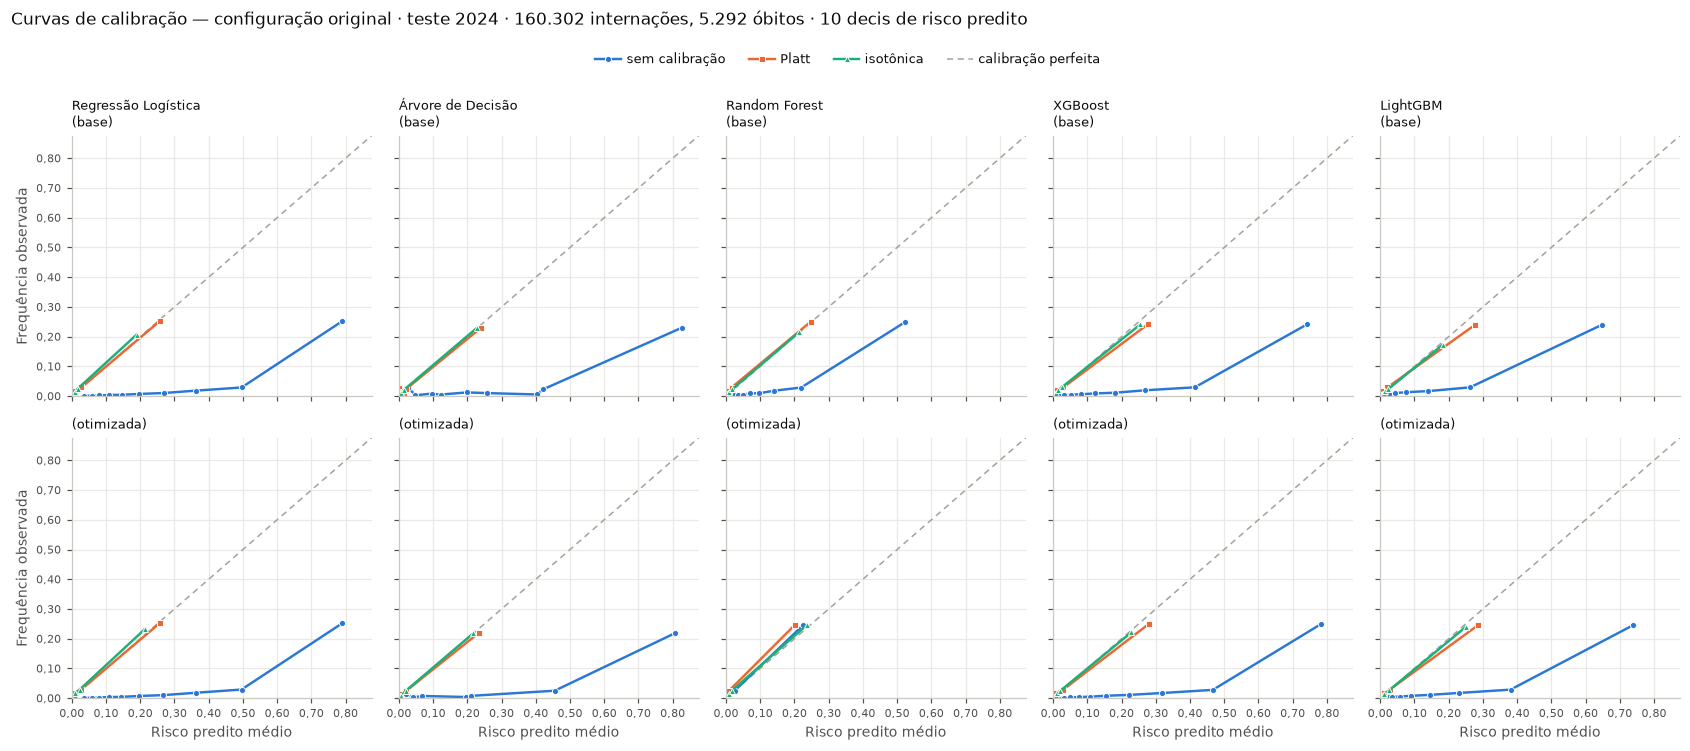

[figura] analysis/plots/calibracao/calibracao_decis_corrigida.png


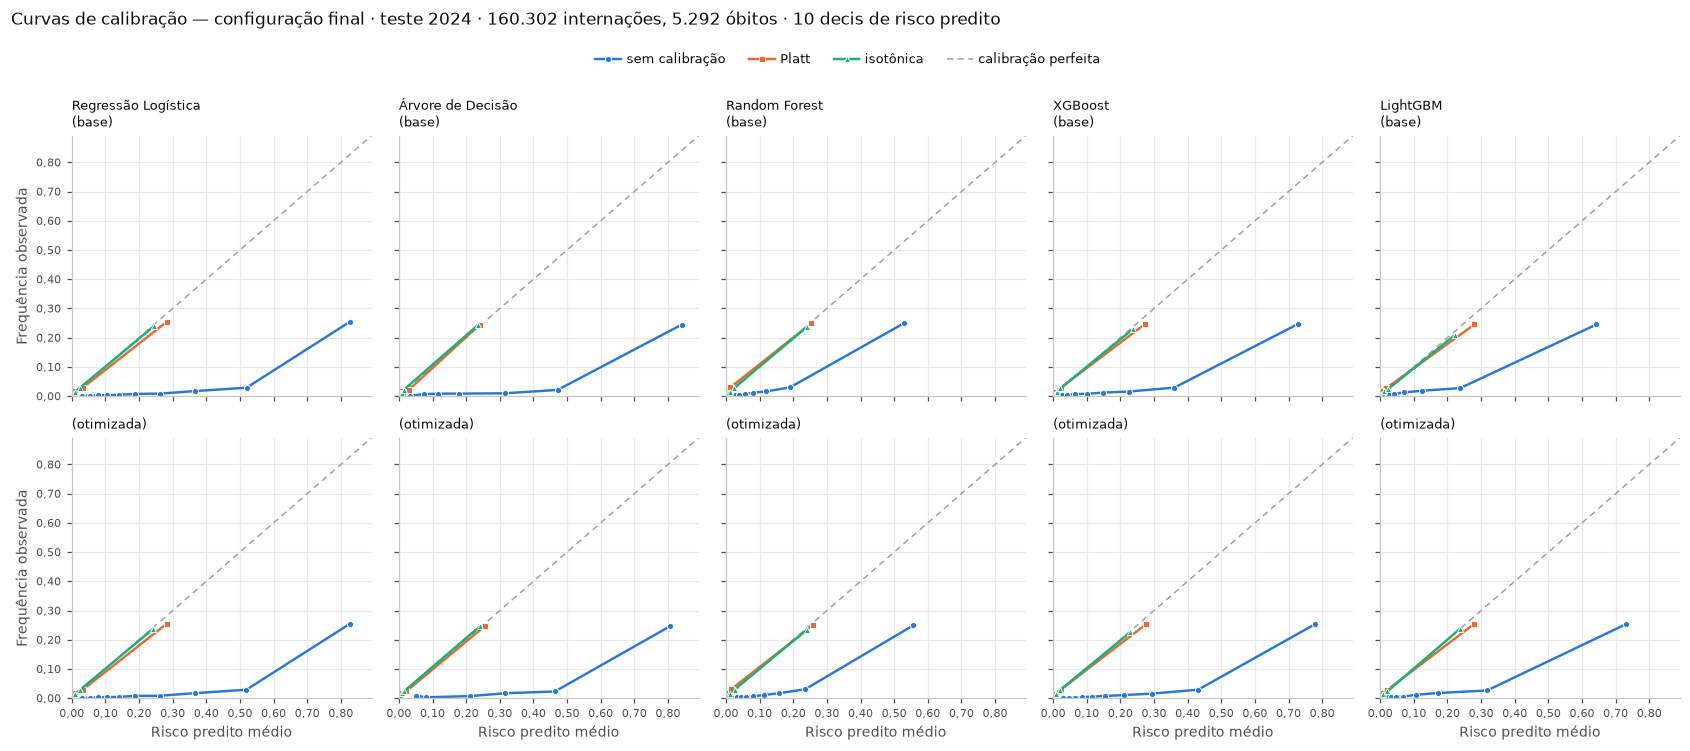

[figura] analysis/plots/calibracao/calibracao_decis_notificacao.png


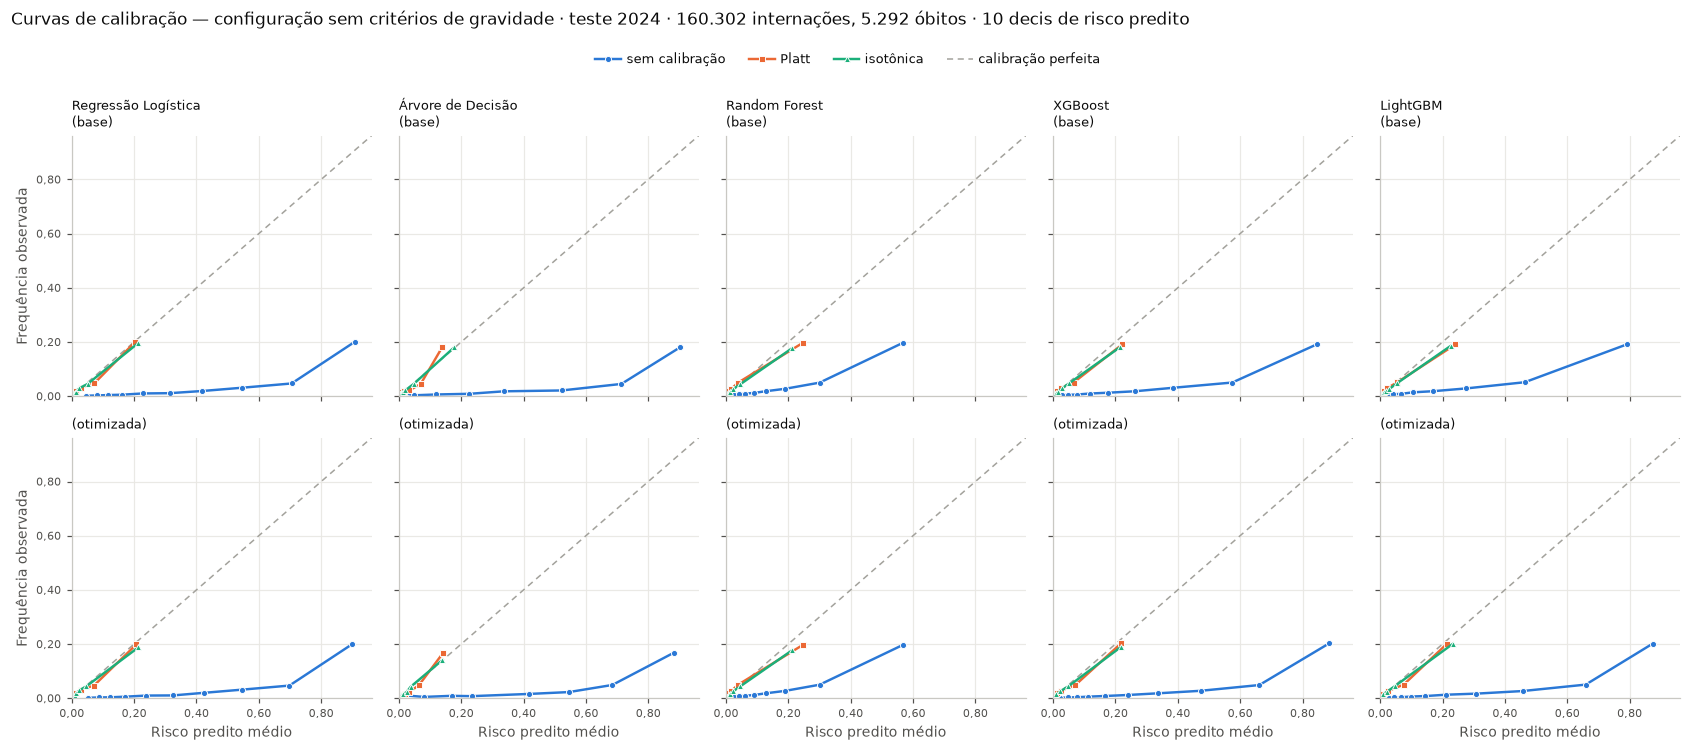

In [12]:
def curva_decis(y, p, n_bins=N_DECIS):
    '''Decis do risco predito: média predita e frequência observada em cada faixa.
    Faixas vazias não entram na curva, o que acontece quando o modelo tem poucos
    patamares de probabilidade e vários decis caem sobre o mesmo valor.'''
    q = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    faixa = np.clip(np.searchsorted(q, p, side='right') - 1, 0, n_bins - 1)
    linhas = []
    for b in range(n_bins):
        m = faixa == b
        if not m.any():
            continue
        linhas.append({'decil': b + 1, 'pred': float(p[m].mean()), 'obs': float(y[m].mean()),
                       'n': int(m.sum()), 'eventos': int(y[m].sum())})
    return pd.DataFrame(linhas)


for cfg in CONFIGS:
    # Uma escala só para os dez painéis: escalas próprias por painel impediriam
    # comparar os modelos entre si.
    curvas, lim = {}, 0.0
    for versao in VERSOES:
        for algo in ALGORITMOS:
            for metodo in CALIBRACOES:
                k = chave_de(algo, cfg, versao, metodo)
                c = curva_decis(Y_TESTE, predicoes[k])
                curvas[k] = (c['pred'].to_numpy(), c['obs'].to_numpy())
                lim = max(lim, c['pred'].max(), c['obs'].max())
    lim = min(1.0, lim * 1.06)

    fig, axes = plt.subplots(2, len(ALGORITMOS), figsize=(15.4, 6.8),
                             sharex=True, sharey=True)
    for i, versao in enumerate(VERSOES):
        for j, algo in enumerate(ALGORITMOS):
            ax = axes[i, j]
            for metodo in CALIBRACOES:
                pred, obs = curvas[chave_de(algo, cfg, versao, metodo)]
                ax.plot(pred, obs, MARCAS_CALIBRACAO[metodo] + '-',
                        color=CORES_CALIBRACAO[metodo], markersize=4, linewidth=1.6,
                        markeredgecolor='#ffffff', markeredgewidth=0.6,
                        label=ROTULO_CALIBRACAO[metodo])
            ax.plot([0, lim], [0, lim], color='#a3a29c', linewidth=1,
                    linestyle=(0, (4, 3)), zorder=1,
                    label='calibração perfeita' if (i, j) == (0, 0) else None)
            ax.set_xlim(0, lim); ax.set_ylim(0, lim)
            ax.set_title(f'{ALGORITMOS[algo]}\n({versao})' if i == 0 else f'({versao})',
                         loc='left', fontsize=8.5)
            ax.grid(True, alpha=0.9, zorder=0); ax.set_axisbelow(True)
            ajustar_eixo(ax, 'x'); ajustar_eixo(ax, 'y')
            ax.tick_params(labelsize=7)
            if j == 0:
                ax.set_ylabel('Frequência observada')
            if i == 1:
                ax.set_xlabel('Risco predito médio')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.955), ncol=4,
               fontsize=8.5, handletextpad=0.4, columnspacing=1.8)
    fig.suptitle(f'Curvas de calibração — configuração {ROTULO_CONFIG[cfg]} · teste 2024 · '
                 f'{n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos · '
                 f'{N_DECIS} decis de risco predito',
                 x=0.006, y=0.995, ha='left', va='top', fontsize=11)
    salvar_fig(fig, f'calibracao_decis_{cfg}.png')
    plt.show()

Figura principal: as curvas de calibração das cinco versões selecionadas da configuração final, um painel por algoritmo, em três colunas na primeira linha e duas na segunda, esta centrada, com a legenda no topo. A versão de cada algoritmo é lida de `selecao_base_vs_otimizada.csv`, gravado acima, pelo mesmo critério dos notebooks 11, 12 e 13, e nunca fixada aqui, para que a figura não possa divergir da seleção; como a seleção é unânime, a versão fica na legenda da figura e no texto, e não se repete em cada painel. Os dois eixos vão a 0,85, de modo que nenhum ponto fica de fora e a diagonal da calibração perfeita corta o painel a 45 graus; a célula confere isso antes de desenhar. A tabela em formato longo grava a curva inteira, e é dela que a figura principal é redesenhada.

,modelo,versao_selecionada,auprc_vc_treino_base,auprc_vc_treino_otimizada,criterio
0,Logistic Regression,otimizada,0.6346,0.6347,maior AUPRC na validação cruzada do treino
1,Decision Tree,otimizada,0.5730,0.6207,maior AUPRC na validação cruzada do treino
2,Random Forest,otimizada,0.6527,0.6530,maior AUPRC na validação cruzada do treino
3,XGBoost,otimizada,0.6298,0.6556,maior AUPRC na validação cruzada do treino
4,LightGBM,otimizada,0.6304,0.6477,maior AUPRC na validação cruzada do treino


Versões selecionadas na configuração final: otimizada. Unânime, então o painel traz só o nome do algoritmo.


[tabela] analysis/results_calibracao/calibracao_decis_final_selecionados.csv  (135 linhas)

Eixos em 0,85 no risco predito e 0,85 na frequência observada. Maior risco predito médio: 0,8272; maior frequência observada: 0,2549.
Pontos fora dos eixos: 0 de 135.


[figura] analysis/plots/calibracao/calibracao_decis_final_selecionados.png  (17,0 cm de largura)


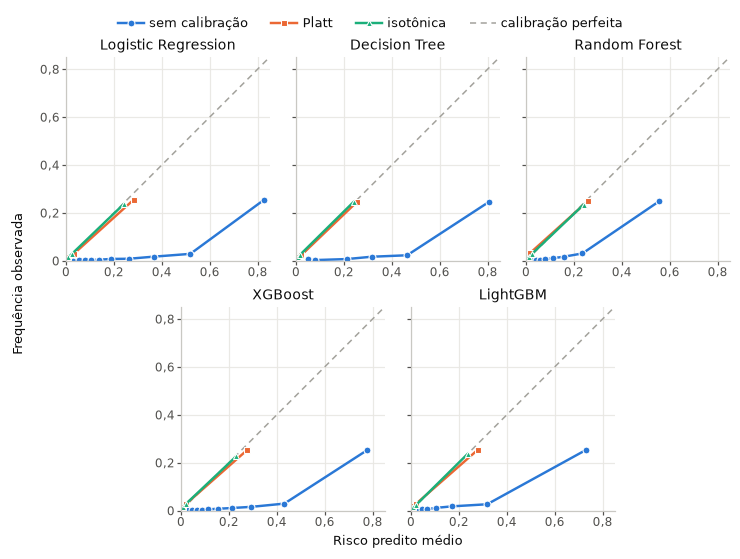

In [13]:
CFG_CORPO  = 'corrigida'
LIM_X_CORPO, LIM_Y_CORPO = 0.85, 0.85
LARGURA_CM = 17.0
ALGO_ORIGINAL = {'logistic_regression': 'Logistic Regression', 'decision_tree': 'Decision Tree',
                 'random_forest': 'Random Forest', 'xgboost': 'XGBoost', 'lightgbm': 'LightGBM'}

# Critério dos notebooks 11, 12 e 13: maior AUPRC média na validação cruzada do treino,
# com empate exato indo para a base por parcimônia.
df_sel_corpo = pd.read_csv(os.path.join(DIR_TABELAS, 'selecao_base_vs_otimizada.csv'))
df_sel_corpo = df_sel_corpo[(df_sel_corpo['configuracao'] == ROTULO_CONFIG[CFG_CORPO])
                            & (df_sel_corpo['calibracao'] == 'Platt')]
versao_corpo, linhas = {}, []
for algo, rotulo in ALGORITMOS.items():
    vc = df_sel_corpo.loc[df_sel_corpo['algoritmo'] == rotulo,
                          ['auprc_vc_treino_base', 'auprc_vc_treino_otimizada']].drop_duplicates()
    assert len(vc) == 1, f'{rotulo}: AUPRC da validação cruzada não é única no artefato'
    base, otim = float(vc.iloc[0, 0]), float(vc.iloc[0, 1])
    versao_corpo[algo] = 'otimizada' if otim > base else 'base'
    linhas.append({'modelo': ALGO_ORIGINAL[algo], 'versao_selecionada': versao_corpo[algo],
                   'auprc_vc_treino_base': base, 'auprc_vc_treino_otimizada': otim,
                   'criterio': ('maior AUPRC na validação cruzada do treino' if otim != base
                                else 'empate exato, base por parcimônia')})
display(pd.DataFrame(linhas))

# Com uma versão só para os cinco algoritmos, dizê-la em cada painel é repetição: fica na
# legenda da figura e no texto. Se a seleção deixar de ser unânime, volta ao título do painel.
VERSOES_SELECIONADAS = sorted(set(versao_corpo.values()))
VERSAO_UNANIME = len(VERSOES_SELECIONADAS) == 1
print(f'Versões selecionadas na configuração {ROTULO_CONFIG[CFG_CORPO]}: '
      f'{", ".join(VERSOES_SELECIONADAS)}. '
      + ('Unânime, então o painel traz só o nome do algoritmo.'
         if VERSAO_UNANIME else 'Não é unânime, então cada painel diz a sua versão.'))

# Curvas e tabela em formato longo: a figura principal e redesenhada daqui.
curvas_corpo, linhas = {}, []
for algo in ALGORITMOS:
    versao = versao_corpo[algo]
    for metodo in CALIBRACOES:
        curva = curva_decis(Y_TESTE, predicoes[chave_de(algo, CFG_CORPO, versao, metodo)])
        curvas_corpo[(algo, metodo)] = curva
        for _, r in curva.iterrows():
            linhas.append({
                'configuracao': ROTULO_CONFIG[CFG_CORPO], 'modelo': ALGO_ORIGINAL[algo],
                'versao': versao, 'calibracao': ROTULO_CALIBRACAO[metodo],
                'decil': int(r['decil']),
                'probabilidade_media_predita': round(r['pred'], 6),
                'frequencia_observada': round(r['obs'], 6),
                'n': int(r['n']), 'eventos': int(r['eventos']),
                'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE})

df_decis_corpo = pd.DataFrame(linhas)
df_decis_corpo['fora_do_recorte'] = np.where(
    (df_decis_corpo['probabilidade_media_predita'] > LIM_X_CORPO)
    | (df_decis_corpo['frequencia_observada'] > LIM_Y_CORPO), 'sim', 'não')
salvar_tab(df_decis_corpo, 'calibracao_decis_final_selecionados.csv')

fora = df_decis_corpo[df_decis_corpo['fora_do_recorte'] == 'sim']
print(f'\nEixos em {v_(LIM_X_CORPO, 2)} no risco predito e {v_(LIM_Y_CORPO, 2)} na frequência '
      f'observada. Maior risco predito médio: '
      f'{v_(df_decis_corpo["probabilidade_media_predita"].max(), 4)}; maior frequência '
      f'observada: {v_(df_decis_corpo["frequencia_observada"].max(), 4)}.')
print(f'Pontos fora dos eixos: {len(fora)} de {len(df_decis_corpo)}.')
if len(fora):
    display(fora[['modelo', 'versao', 'calibracao', 'decil', 'probabilidade_media_predita',
                  'frequencia_observada', 'n']])

# Medidas em polegadas: a figura sai com 17 cm de largura, sem bbox_inches='tight', e as
# margens são as menores que acomodam as marcas de escala, para que os painéis fiquem com o
# máximo do espaço horizontal. Três colunas na primeira linha e duas na segunda, esta centrada
# no bloco, de modo que o rótulo único do eixo x fique simétrico entre os dois painéis.
# X_ROTULO_Y é a folga do rótulo do eixo y até as marcas de escala.
larg_pol = LARGURA_CM / 2.54
COLUNAS = 3
LINHAS = int(np.ceil(len(ALGORITMOS) / COLUNAS))
ESQ, DIREITA, TOPO, VAO_H, VAO_V = 0.58, 0.08, 0.46, 0.24, 0.42
X_ROTULO_Y = 0.08
BAIXO = 0.42 + (0.20 if len(fora) else 0.0)
painel_larg = (larg_pol - ESQ - DIREITA - (COLUNAS - 1) * VAO_H) / COLUNAS
painel_alt = painel_larg * LIM_Y_CORPO / LIM_X_CORPO
alt_pol = LINHAS * painel_alt + (LINHAS - 1) * VAO_V + TOPO + BAIXO
bloco_larg = COLUNAS * painel_larg + (COLUNAS - 1) * VAO_H
bloco_alt = LINHAS * painel_alt + (LINHAS - 1) * VAO_V

fig = plt.figure(figsize=(larg_pol, alt_pol))
eixos = []
for j, algo in enumerate(ALGORITMOS):
    linha, coluna = divmod(j, COLUNAS)
    n_na_linha = min(COLUNAS, len(ALGORITMOS) - linha * COLUNAS)
    recuo = (COLUNAS - n_na_linha) * (painel_larg + VAO_H) / 2
    ax = fig.add_axes([(ESQ + recuo + coluna * (painel_larg + VAO_H)) / larg_pol,
                       (BAIXO + (LINHAS - 1 - linha) * (painel_alt + VAO_V)) / alt_pol,
                       painel_larg / larg_pol, painel_alt / alt_pol])
    eixos.append(ax)
    for metodo in CALIBRACOES:
        curva = curvas_corpo[(algo, metodo)]
        ax.plot(curva['pred'], curva['obs'], MARCAS_CALIBRACAO[metodo] + '-',
                color=CORES_CALIBRACAO[metodo], markersize=4.5, linewidth=1.6,
                markeredgecolor='#ffffff', markeredgewidth=0.7,
                label=ROTULO_CALIBRACAO[metodo])
    diagonal = min(LIM_X_CORPO, LIM_Y_CORPO)
    ax.plot([0, diagonal], [0, diagonal], color='#a3a29c', linewidth=1,
            linestyle=(0, (4, 3)), zorder=1,
            label='calibração perfeita' if j == 0 else None)
    ax.set_xlim(0, LIM_X_CORPO); ax.set_ylim(0, LIM_Y_CORPO)
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.xaxis.set_major_formatter(eixo_virgula_curto(1))
    ax.yaxis.set_major_formatter(eixo_virgula_curto(1))
    ax.tick_params(labelsize=8, length=2.5, pad=1.5)
    ax.grid(True, alpha=0.9, zorder=0); ax.set_axisbelow(True)
    ax.set_title(ALGO_ORIGINAL[algo] if VERSAO_UNANIME
                 else f'{ALGO_ORIGINAL[algo]} (versão {versao_corpo[algo]})',
                 fontsize=9, pad=5)
    if coluna > 0:
        ax.set_yticklabels([])

# Um rótulo por eixo, no centro do bloco de painéis. Com a última linha centrada, esse centro
# cai dentro do trecho que ela ocupa; a trava pega o caso em que deixaria de cair.
centro = ESQ + bloco_larg / 2
n_ultima = len(ALGORITMOS) - (LINHAS - 1) * COLUNAS
recuo_ultima = (COLUNAS - n_ultima) * (painel_larg + VAO_H) / 2
inicio_ultima = ESQ + recuo_ultima
fim_ultima = inicio_ultima + n_ultima * painel_larg + (n_ultima - 1) * VAO_H
assert inicio_ultima <= centro <= fim_ultima, (
    'o rótulo do eixo x cairia fora da última linha: reveja COLUNAS ou o recuo')
fig.text(centro / larg_pol, (BAIXO - 0.34) / alt_pol,
         'Risco predito médio', ha='center', va='bottom', fontsize=8.5)
fig.text(X_ROTULO_Y / larg_pol, (BAIXO + bloco_alt / 2) / alt_pol, 'Frequência observada',
         ha='left', va='center', rotation=90, fontsize=8.5)

handles, labels = eixos[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, (alt_pol - 0.04) / alt_pol),
           ncol=4, fontsize=8.5, handletextpad=0.4, columnspacing=1.8, borderaxespad=0)
if len(fora):
    fig.text(0.005, 0.012,
             f'{len(fora)} dos {len(df_decis_corpo)} pontos ficam fora dos eixos.',
             fontsize=8.5, color='#52514e', ha='left', va='bottom')
salvar_fig(fig, 'calibracao_decis_final_selecionados.png', bbox=None)
plt.show()

Número de valores distintos de probabilidade predita no teste de 2024, nos três estados de calibração, para as mesmas cinco versões selecionadas. Com dez decis os patamares ficam encobertos, mas na escala recortada podem aparecer como degraus, e a diagramação precisa saber disso antes de redesenhar a figura.

In [14]:
linhas = []
for algo in ALGORITMOS:
    versao = versao_corpo[algo]
    for metodo in CALIBRACOES:
        p = predicoes[chave_de(algo, CFG_CORPO, versao, metodo)]
        linhas.append({
            'modelo': ALGO_ORIGINAL[algo], 'versao': versao,
            'calibracao': ROTULO_CALIBRACAO[metodo],
            'valores_distintos': int(np.unique(p).size),
            'decis_ocupados': int(len(curvas_corpo[(algo, metodo)])),
            'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
        })

df_patamares = salvar_tab(pd.DataFrame(linhas), 'patamares_predicoes_final.csv')
display(df_patamares[['modelo', 'versao', 'calibracao', 'valores_distintos', 'decis_ocupados']])

for algo in ALGORITMOS:
    sub = df_patamares[df_patamares['modelo'] == ALGO_ORIGINAL[algo]]
    print(f'{ALGO_ORIGINAL[algo]:<20} ' + ' · '.join(
        f'{r["calibracao"]}: {n_(r["valores_distintos"])} valores, '
        f'{r["decis_ocupados"]} decis' for _, r in sub.iterrows()))

[tabela] analysis/results_calibracao/patamares_predicoes_final.csv  (15 linhas)


,modelo,versao,calibracao,valores_distintos,decis_ocupados
0,Logistic Regression,otimizada,sem calibração,158801,10
1,Logistic Regression,otimizada,Platt,158800,10
2,Logistic Regression,otimizada,isotônica,184,10
3,Decision Tree,otimizada,sem calibração,31,6
4,Decision Tree,otimizada,Platt,31,6
5,Decision Tree,otimizada,isotônica,19,6
6,Random Forest,otimizada,sem calibração,156915,10
7,Random Forest,otimizada,Platt,156915,10
8,Random Forest,otimizada,isotônica,161,9
9,XGBoost,otimizada,sem calibração,137153,10


Logistic Regression  sem calibração: 158.801 valores, 10 decis · Platt: 158.800 valores, 10 decis · isotônica: 184 valores, 10 decis
Decision Tree        sem calibração: 31 valores, 6 decis · Platt: 31 valores, 6 decis · isotônica: 19 valores, 6 decis
Random Forest        sem calibração: 156.915 valores, 10 decis · Platt: 156.915 valores, 10 decis · isotônica: 161 valores, 9 decis
XGBoost              sem calibração: 137.153 valores, 10 decis · Platt: 137.153 valores, 10 decis · isotônica: 172 valores, 9 decis
LightGBM             sem calibração: 156.827 valores, 10 decis · Platt: 156.827 valores, 10 decis · isotônica: 163 valores, 9 decis


Curva de sensibilidade contra VPP ao longo dos limiares, uma figura por configuração.

[figura] analysis/plots/calibracao/sensibilidade_vpp_antiga.png


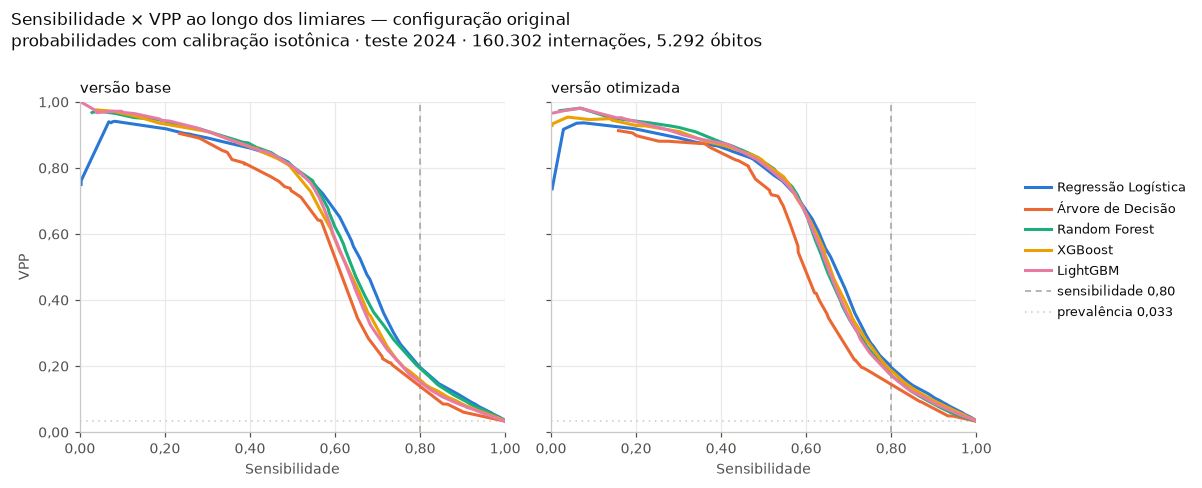

[figura] analysis/plots/calibracao/sensibilidade_vpp_corrigida.png


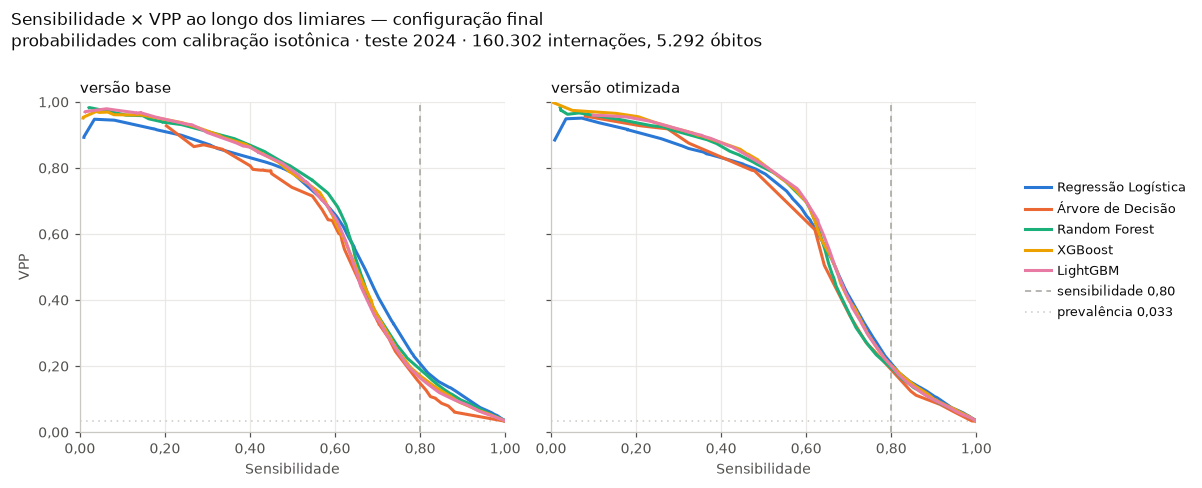

[figura] analysis/plots/calibracao/sensibilidade_vpp_notificacao.png


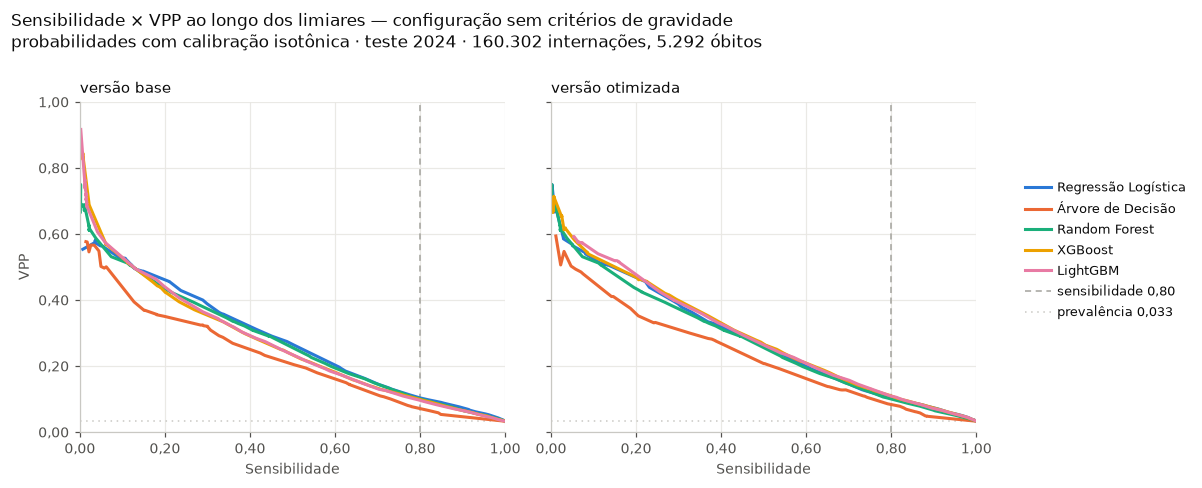

In [15]:
def curva_sens_vpp(y, p, n_pontos=200):
    '''Sensibilidade e VPP em cada limiar distinto, reduzidos a uma grade legível.'''
    y = np.asarray(y, dtype=np.float64)
    ordem = np.argsort(-np.asarray(p, dtype=np.float64), kind='stable')
    p_ord, y_ord = np.asarray(p)[ordem], y[ordem]
    corte = np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1]
    vp = np.cumsum(y_ord)[corte]
    total = corte + 1
    sens = vp / max(vp[-1], 1e-12)
    vpp = vp / total
    if len(sens) > n_pontos:
        idx = np.unique(np.linspace(0, len(sens) - 1, n_pontos).astype(int))
        sens, vpp = sens[idx], vpp[idx]
    return sens, vpp


for cfg in CONFIGS:
    fig, axes = plt.subplots(1, len(VERSOES), figsize=(11.4, 4.4), sharey=True)
    for ax, versao in zip(axes, VERSOES):
        for algo in ALGORITMOS:
            k = chave_de(algo, cfg, versao, 'isotonica')
            sens, vpp = curva_sens_vpp(Y_TESTE, predicoes[k])
            ax.plot(sens, vpp, color=CORES_ALGO[algo], linewidth=2, label=ALGORITMOS[algo])
        ax.axvline(SENS_ALVO, color='#a3a29c', linewidth=1, linestyle=(0, (4, 3)), zorder=1,
                   label=f'sensibilidade {v_(SENS_ALVO, 2)}')
        ax.axhline(PREVALENCIA, color='#c9c8c3', linewidth=1, linestyle=(0, (1, 3)), zorder=1,
                   label=f'prevalência {v_(PREVALENCIA, 3)}')
        ax.set_title(f'versão {versao}', loc='left', fontsize=10)
        ax.set_xlabel('Sensibilidade'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.9, zorder=0); ax.set_axisbelow(True)
        ajustar_eixo(ax, 'x'); ajustar_eixo(ax, 'y')
    axes[0].set_ylabel('VPP')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.tight_layout(rect=(0, 0, 0.80, 0.88))
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.805, 0.5), fontsize=8.5,
               handletextpad=0.5)
    fig.suptitle(f'Sensibilidade × VPP ao longo dos limiares — configuração '
                 f'{ROTULO_CONFIG[cfg]}\nprobabilidades com calibração isotônica · teste 2024 · '
                 f'{n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos',
                 x=0.006, y=0.995, ha='left', va='top', fontsize=11)
    salvar_fig(fig, f'sensibilidade_vpp_{cfg}.png')
    plt.show()

## Conclusões

- Ressalva que vale para todo o limiar reportado aqui: ele é lido nas mesmas predições fora da
  partição que ajustaram o calibrador, de modo que a sensibilidade medida no treino é um pouco
  otimista.
  A tabela de limiares traz a sensibilidade do treino e a obtida em 2024 lado a lado,
  e é a segunda que mede o que de fato transfere.

- O atalho de ajustar os dois calibradores sobre as mesmas predições fora da partição reproduz o
  `CalibratedClassifierCV` do scikit-learn com diferença exatamente zero nas 160.302
  probabilidades, nos dois métodos.

- A calibração corrige o Brier Skill Score negativo.
  Antes, 28 dos 30 modelos têm valor negativo, com mediana -1,9262 e pior caso -4,7185.
  Depois, nenhum dos 30 fica negativo: mediana 0,3569 com Platt e 0,4343 com a isotônica, contra
  a prevalência observada de 3,3% no teste de 2024.

- O Brier mediano cai de 0,0934 sem calibração para 0,0205 com Platt e 0,0181 com a isotônica.

- A isotônica supera o Platt no Brier Skill Score nos 30 modelos.
  O melhor valor do conjunto é 0,4606 [0,4478; 0,4734], do LightGBM otimizado na configuração
  final.

- O Platt preserva a ordenação: o ROC-AUC não muda em nenhum modelo e o AUPRC muda no máximo
  1×10⁻⁴.
  A isotônica cria empates e reduz o AUPRC nos 30 modelos, com mediana de -0,0109 e queda máxima
  de 0,0149.

- O limiar de 0,5 deixa de separar as classes sobre probabilidades calibradas.
  A sensibilidade mediana cai de 0,7449 para 0,5030 com Platt e 0,4930 com a isotônica, e em 11
  dos 30 modelos calibrados por Platt nenhuma internação de 2024 alcança 0,5: zero verdadeiros e
  zero falsos positivos.

- O limiar que atinge sensibilidade 0,80 na validação cruzada do treino fica entre 0,0064 e
  0,0388, com mediana 0,0178, nas probabilidades com calibração Platt, e entre 0,0066 e 0,0340,
  com mediana 0,0205, nas com a isotônica.

- Esse limiar transfere para 2024 sem ajuste: a diferença entre a sensibilidade medida no treino
  e a obtida no teste tem mediana de 0,0131 e vai de -0,0669 a 0,0655.
  Os 30 modelos alcançam o alvo no treino.

- No limiar do alvo, a mediana é de 4.331 verdadeiros positivos contra 29.524 falsos positivos,
  com VPP mediano de 0,129, entre 0,033 e 0,233.

- Por configuração, o Brier Skill Score mediano depois da isotônica é 0,4473 na original, 0,4402 na
  final e 0,1404 na sem critérios de gravidade.

- O empate exato entre base e otimizada mudou de lugar.
  No Random Forest da configuração final a busca em grade deixou de devolver os
  hiperparâmetros da base — passou a escolher `max_features='log2'` — e a otimizada vence por
  0,0003 na AUPRC da validação cruzada, 0,6530 contra 0,6527: os cinco algoritmos da final
  ficam agora com a versão otimizada.
  O empate reaparece no Random Forest da configuração sem critérios de gravidade, 0,2755 nas duas versões,
  que fica com a base por parcimônia.
  No conjunto, 14 dos 15 pares ficam com a otimizada, como antes.

- A figura principal traz as cinco versões selecionadas da configuração final, um
  painel por algoritmo, e as cinco são a versão otimizada.
  A seleção é lida de `selecao_base_vs_otimizada.csv` na própria célula, pelo mesmo critério dos
  notebooks 11, 12 e 13, e não é fixada no código.
  A margem mais estreita é a do Random Forest, 0,6530 contra 0,6527 na AUPRC da validação cruzada
  do treino.
  Como a seleção é unânime, a versão não se repete em cada painel: fica na legenda da figura e no
  texto. Se deixar de ser unânime, a célula volta a escrevê-la no título de cada painel.

- Os dois eixos da figura do corpo vão a 0,85 e nenhum dos 135 pontos fica de fora, o que a
  célula confere antes de desenhar.
  O alcance é imposto só pela curva sem calibração, que chega a 0,8272 no decil superior da
  Logistic Regression; Platt para em 0,2824 e a regressão isotônica em 0,2412, e a maior
  frequência observada é 0,2549 nos três estados.
  Com a escala inteira, as curvas calibradas ficam num canto que ocupa cerca de um terço do lado
  do painel, e é o contraste com o modelo não calibrado que paga esse espaço.
  A tabela `calibracao_decis_final_selecionados.csv` grava as curvas inteiras, e é dela que a
  figura principal é redesenhada.

- Decision Tree é o modelo com menos patamares de probabilidade no teste de 2024: 31 valores
  distintos sem calibração e com Platt, e 19 depois da regressão isotônica.
  Os dez decis caem sobre seis faixas, de modo que a curva tem seis pontos e não dez.
  Os outros quatro algoritmos vão de 137.153 a 158.801 valores distintos sem calibração e de 161
  a 184 depois da isotônica, com nove ou dez decis ocupados.
  Na escala recortada esses patamares podem aparecer como degraus, e a diagramação precisa
  contar com isso.